In [1]:
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import trange

from landlab import RasterModelGrid
from landlab import load_params
from landlab.components import FlowAccumulator, ErosionDeposition, LinearDiffuser 
from landlab.plot.layers import plot_layers
from landlab.io.netcdf import write_raster_netcdf



In [2]:
input_file = "model_params_upd.yaml"
inputs = load_params(input_file)  # load the data into a dictionary

In [3]:
import pandas as pd

df = pd.read_csv('data/node_66Ma.csv', sep = ' ', header = None)
uplift_66_56 = pd.read_csv('data/uplift_66to56Ma.csv', sep = ' ', header = None)
uplift_56_34 = pd.read_csv('data/uplift_56to34Ma.csv', sep = ' ', header = None)
precip = pd.read_csv('data/precip_66Ma.csv', sep = ' ', header = None)

In [4]:
#df.head()
#df[2]
#uplift[0]

In [5]:
elevation = df[2]
uplift_1 = uplift_66_56[0]
uplift_2 = uplift_56_34[0]
precip = precip[0]

In [6]:
elevation

0      -3224.05
1      -3833.84
2      -4301.69
3      -4335.44
4      -4171.70
         ...   
9595   -4984.01
9596   -4983.99
9597   -4983.90
9598   -4983.99
9599   -4984.01
Name: 2, Length: 9600, dtype: float64

In [7]:
uplift_val_1 = uplift_1.to_numpy()
uplift_val_2 = uplift_2.to_numpy()
uplift_val_2

array([-3968.89, -4283.67, -4688.56, ...,   578.46,   621.94,   498.38],
      shape=(9600,))

In [8]:
precip_val = precip.to_numpy()
precip_val

array([0.52, 0.53, 0.53, ..., 2.01, 2.02, 2.02], shape=(9600,))

In [9]:
nrows = inputs["nrows"]
ncols = inputs["ncols"]
dx = inputs["dx"]
dy = inputs["dy"]
runoff_coef = inputs["runoff_coef"]

print(inputs)

{'nrows': 120, 'ncols': 80, 'dx': 50000, 'dy': 50000, 'runoff_coef': 0.3, 'stream_power': {'K': 2e-08, 'm_sp': 0.5, 'sp_crit': 5e-05, 'v_s': 10.0, 'F_f': 0.2}, 'linear_diffuser': {'linear_diffusivity': 0.0001}}


In [10]:
total_t = 10000000
dt = 100000
nt = int(total_t // dt)  # this is how many loops we'll need

In [11]:
uplift_per_step_1 = uplift_val_1*dt/total_t
uplift_per_step_2 = uplift_val_2*dt/22000000

In [12]:
uplift_per_step_2

array([-18.04040909, -19.47122727, -21.31163636, ...,   2.62936364,
         2.827     ,   2.26536364], shape=(9600,))

In [13]:
mg = RasterModelGrid((nrows, ncols), xy_spacing = (dx, dy))
z = mg.add_zeros("topographic__elevation", at="node")
z+= elevation.values
for edge in (mg.nodes_at_left_edge, mg.nodes_at_right_edge, mg.nodes_at_top_edge, mg.nodes_at_bottom_edge):
    mg.status_at_node[edge] = mg.BC_NODE_IS_FIXED_GRADIENT  # Enforces a constant slope (gradient) at the boundary.

In [14]:
z

array([-3224.05, -3833.84, -4301.69, ..., -4983.9 , -4983.99, -4984.01],
      shape=(9600,))

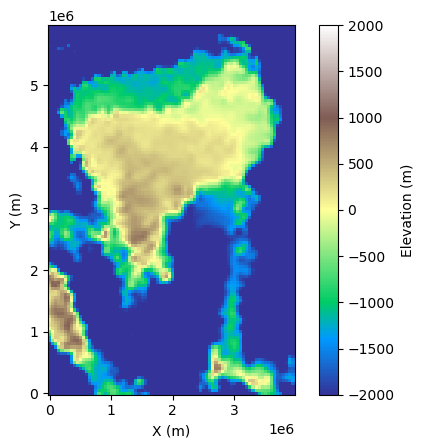

In [15]:
mg.imshow("topographic__elevation", grid_units=("m", "m"), var_name="Elevation (m)", cmap="terrain", symmetric_cbar=True, vmin=-2000, vmax=2000)

In [16]:
mg.add_field('Precipitation map', precip_val, at='node')
runoff_rate = precip_val*runoff_coef
mg.add_field('runoff', runoff_rate, at='node')

array([0.156, 0.159, 0.159, ..., 0.603, 0.606, 0.606], shape=(9600,))

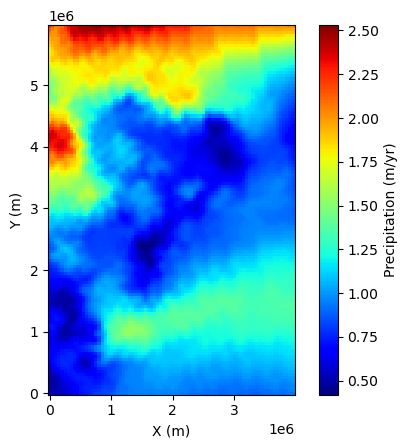

In [17]:
mg.imshow("Precipitation map", grid_units=("m", "m"), var_name="Precipitation (m/yr)", cmap="jet")

In [18]:
fr = FlowAccumulator(mg, flow_director='FlowDirectorD8', depression_finder='DepressionFinderAndRouter', runoff_rate='runoff')  #Calculates drainage area and flow direction at each node based on elevation (Routes flow using D4/SteepestDescent, D8, MFD etc).
sp = ErosionDeposition(mg, **inputs["stream_power"], solver="adaptive")  # Modifies "topographic__elevation" based on water discharge and slope.
lin_diffuse = LinearDiffuser(mg, **inputs["linear_diffuser"]) # Simulates hillslope diffusion (mass movement, soil creep), Smooths elevation over time.

In [19]:
print(mg.at_node['runoff'])
#print(mg.at_node['water__unit_flux_in'])

[0.156 0.159 0.159 ... 0.603 0.606 0.606]


In [20]:
sd = mg.add_zeros('sediment_deposition', at='node')

In [21]:
# Choose your cross-section parameters
fixed_row = 90
col_start, col_end = 0, 79

start, end = sorted([col_start, col_end])
cross_section_indices = [fixed_row * 80 + c for c in range(start, end + 1)]
elevation_history = []

In [22]:
len(cross_section_indices)

80

# Loop 66 to 56 Ma

In [23]:

for i in trange(nt):

    #write_raster_netcdf(
     #   f"Elevation_Transport_Limited/elevation_step_{i:05d}.nc",
      #  mg,
       # names="topographic__elevation",
    #)
    
    # Extract elevation values along the cross-section for this time step
    if i % 10 == 0:
        current_elevation = mg.at_node["topographic__elevation"][cross_section_indices]
        elevation_history.append(current_elevation.copy())

    lin_diffuse.run_one_step(dt) 
    # fr isn't time sensitive (just updates flow fields, no dt needed)
    fr.run_one_step()
    sp.run_one_step(dt)
    
    # sediment deposition code
    net_deposition_rate = mg.at_node['sediment__influx'] - mg.at_node['sediment__outflux']
    net_deposition = net_deposition_rate*dt
    net_deposition_thickness = net_deposition/(dx*dy)
    sd += net_deposition_thickness
    # sediment deposition code ends
    
    # add the uplift
    mg.at_node["topographic__elevation"] += uplift_per_step_1

# Order: Slopes evolve → flow adjust → erosion act → uplift renew

  0%|          | 0/100 [00:00<?, ?it/s]

# Stratigraphy Plot

In [24]:
elevation_at_layer = np.array(elevation_history)
elevation_at_layer.shape

(10, 80)

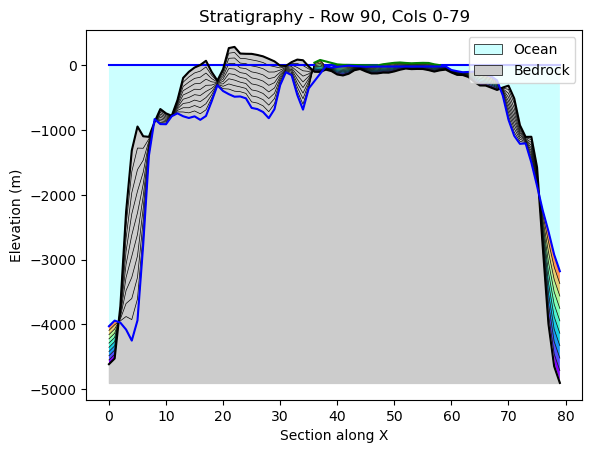

In [25]:
plot_layers(
    elevation_at_layer,
    x=np.arange(len(cross_section_indices)),
    title= f'Stratigraphy - Row {fixed_row}, Cols {start}-{end}',
    legend_location='upper right',
    y_label='Elevation (m)',
    x_label='Section along X',
    color_layer = 'rainbow',
    #color_bedrock = (0.6,0.4,0.2)
)


# Elevation Plot

In [26]:
z

array([ 585.26      , 1017.96272062,  992.32791263, ...,  853.50647236,
       1191.35793337, 1084.23      ], shape=(9600,))

In [27]:
#updated_elevation = mg.at_node['topographic__elevation']
#np.savetxt('node_56Ma_LEM.csv', updated_elevation, fmt='%.2f')

In [28]:
sd.max()

np.float64(1425.980024992915)

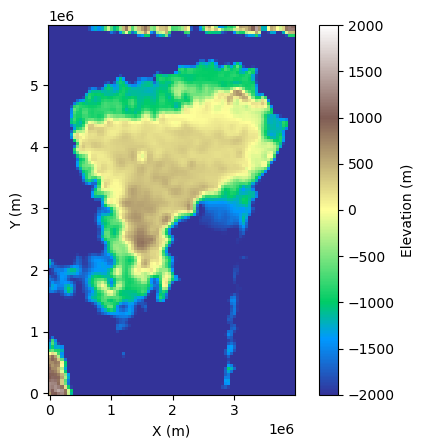

In [29]:
mg.imshow("topographic__elevation", grid_units=["m", "m"], var_name="Elevation (m)", cmap="terrain", symmetric_cbar=True, vmin=-2000, vmax=2000)

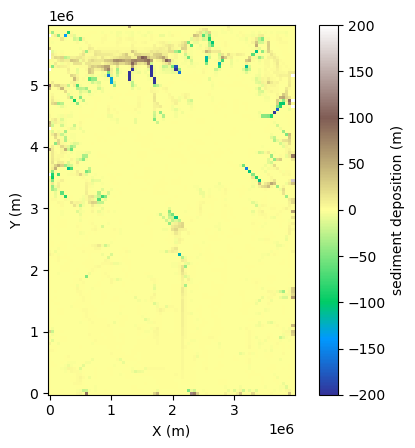

In [30]:
mg.imshow("sediment_deposition", grid_units=["m", "m"], vmin=-200, vmax=200, var_name="sediment deposition (m)", cmap="terrain")

# Loop 56 to 34 Ma

In [31]:
total_t = 22000000
dt = 100000
nt = int(total_t // dt)

In [32]:
for i in trange(nt):

    #write_raster_netcdf(
     #   f"Elevation_Transport_Limited/elevation_step_{i:05d}.nc",
      #  mg,
       # names="topographic__elevation",
    #)
    
    # Extract elevation values along the cross-section for this time step
    if i % 10 == 0:
        current_elevation = mg.at_node["topographic__elevation"][cross_section_indices]
        elevation_history.append(current_elevation.copy())

    lin_diffuse.run_one_step(dt) 
    # fr isn't time sensitive (just updates flow fields, no dt needed)
    fr.run_one_step()
    sp.run_one_step(dt)
    
    # sediment deposition code
    net_deposition_rate = mg.at_node['sediment__influx'] - mg.at_node['sediment__outflux']
    net_deposition = net_deposition_rate*dt
    net_deposition_thickness = net_deposition/(dx*dy)
    sd += net_deposition_thickness
    # sediment deposition code ends
    
    # add the uplift
    mg.at_node["topographic__elevation"] += uplift_per_step_2


  0%|          | 0/220 [00:00<?, ?it/s]

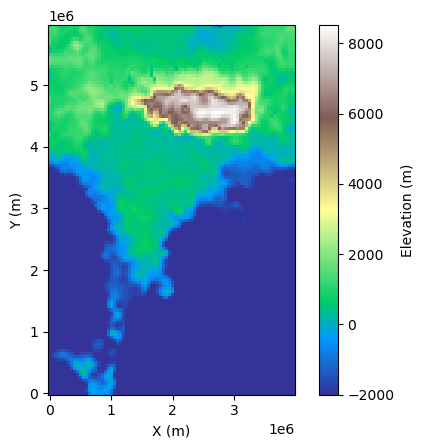

In [33]:
mg.imshow("topographic__elevation", grid_units=["m", "m"], var_name="Elevation (m)", cmap="terrain", symmetric_cbar=True, vmin=-2000)

In [34]:
elevation_at_layer = np.array(elevation_history)
elevation_at_layer.shape

(32, 80)

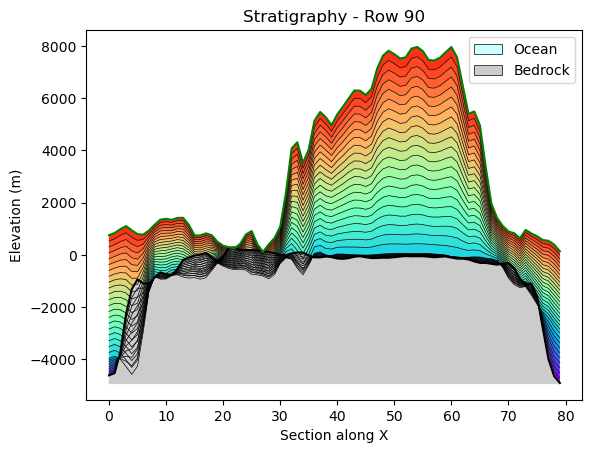

In [41]:
plot_layers(
    elevation_at_layer,
    x=np.arange(len(cross_section_indices)),
    title= f'Stratigraphy - Row {fixed_row}',
    legend_location='upper right',
    y_label='Elevation (m)',
    x_label='Section along X',
    color_layer = 'rainbow'
)


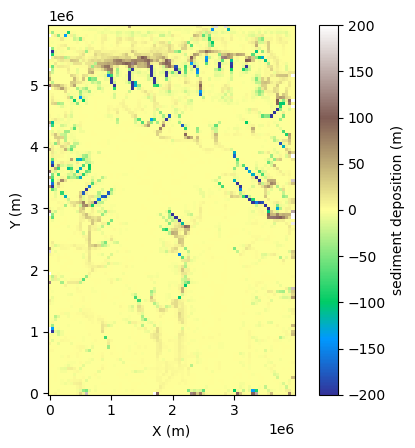

In [39]:
mg.imshow("sediment_deposition", grid_units=["m", "m"], vmin=-200, vmax=200, var_name="sediment deposition (m)", cmap="terrain")